In [ ]:
import pandas as pd
from utilsforecast.plotting import plot_series

melsyd_economy = (
    pd.read_csv("data/ansett.csv", parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD")
        & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
)



In [ ]:
import matplotlib.pyplot as plt

plt.plot(melsyd_economy["ds"], melsyd_economy["y"])
plt.xlabel("Week [1W]")
plt.ylabel("Passengers ('000)")
plt.title("Ansett airlines economy class: Melbourne-Sydney")
plt.show()

In [ ]:
pbs = (
    pd.read_csv("data/PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)

total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .assign(Cost=lambda x: (x["Cost"] / 1e6).round(2))
)
total_cost_df

In [ ]:
import matplotlib.pyplot as plt

df = total_cost_df.assign()

plt.figure()

plt.plot(df["Month"], df["Cost"])

plt.xlabel("Month [1M]")
plt.ylabel("$ (millions)")
plt.title("Australian antidiabetic drug sales")

plt.show()

In [146]:
df = total_cost_df.assign(
    Month_name=total_cost_df["Month"].dt.strftime("%b"),
    Year=total_cost_df["Month"].dt.year,
    Month_num=total_cost_df["Month"].dt.month,
)
df

,Month,Cost,Month_name,Year,Month_num
0,1991-07-01,3.53,Jul,1991,7
1,1991-08-01,3.18,Aug,1991,8
2,1991-09-01,3.25,Sep,1991,9
3,1991-10-01,3.61,Oct,1991,10
4,1991-11-01,3.57,Nov,1991,11
...,...,...,...,...,...
199,2008-02-01,21.65,Feb,2008,2
200,2008-03-01,18.26,Mar,2008,3
201,2008-04-01,23.11,Apr,2008,4
202,2008-05-01,22.91,May,2008,5


In [ ]:
import seaborn as sns

unique_years = df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(data=df, x="Month_num", y="Cost",
  hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)

min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Cost"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=9, weight="bold", color=color)

fig.show()

In [ ]:
for year, subset in df.groupby("Year"):
    print(year)
    print(subset)

In [ ]:
import pandas as pd
tourism = pd.read_csv('data/tourism.csv', sep=',', na_values=[''], quotechar='"')
tourism.head(5)

In [ ]:
tourism["ds"] = pd.to_datetime(tourism["ds"])
tourism.info()

In [ ]:
df = tourism.assign(
    Year =  tourism["ds"].dt.year,
    Quarter="Q" + tourism["ds"].dt.quarter.astype("string"),
).loc[lambda tourism : tourism["Purpose"]=="Holiday"]

df

In [ ]:
num_states, num_years = df[["State", "Year"]].nunique()


In [ ]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))

/var/folders/j6/_hyc3_ws1l79hl_82gf7_9dm0000gn/T/ipykernel_5666/917851760.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


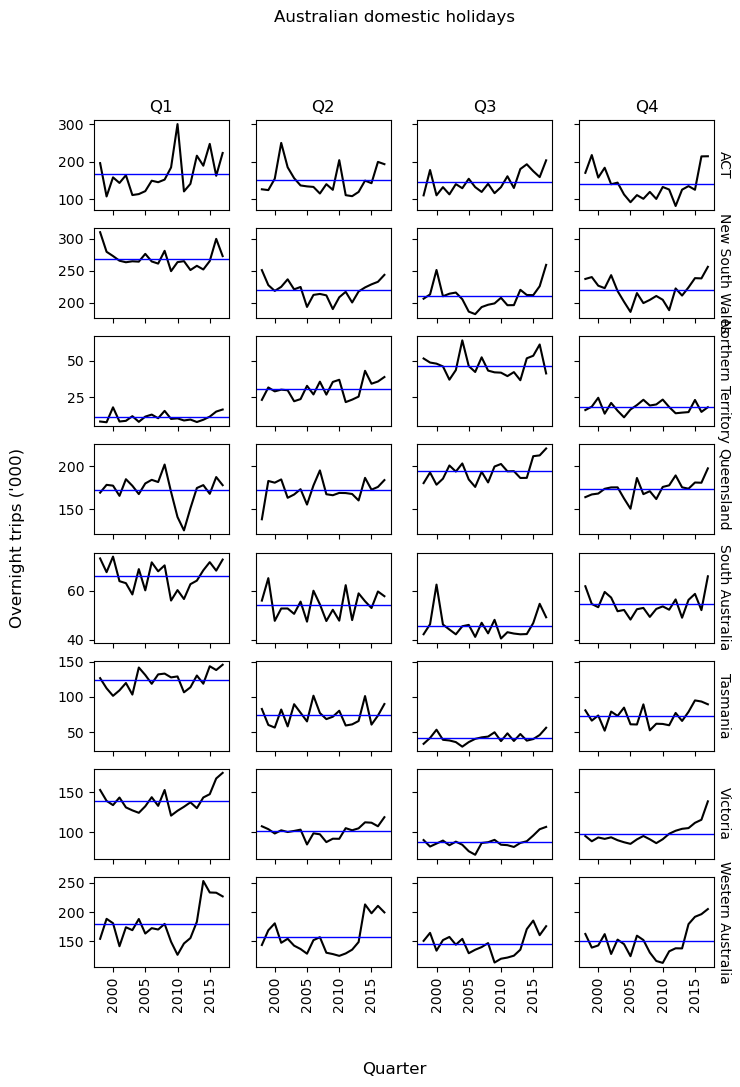

In [145]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))


for ax, ((state, quarter), sq_df) in zip(
        axes.flat, df.groupby(["State", "Quarter"])):
    sq_df = (
    sq_df.groupby("Year", as_index=False)["y"]
    .mean()
    .sort_values("Year")
    )
    ax.plot(sq_df["Year"], sq_df["y"], color="k")
    ax.axhline(sq_df["y"].mean(), color="b", linewidth=1)
    ax.tick_params(axis="x", rotation=90)
    xticks = sq_df["Year"].loc[lambda x: (x % 5) == 0]
    if ax in axes[0]:
        ax.set(title=quarter, xticks=xticks)
    if ax in axes[:, -1]:
        ax.text(1.02, 0.5, state, va="center", ha="left", rotation=270,
            size="medium", transform=ax.transAxes)
fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

/var/folders/j6/_hyc3_ws1l79hl_82gf7_9dm0000gn/T/ipykernel_5666/909721357.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


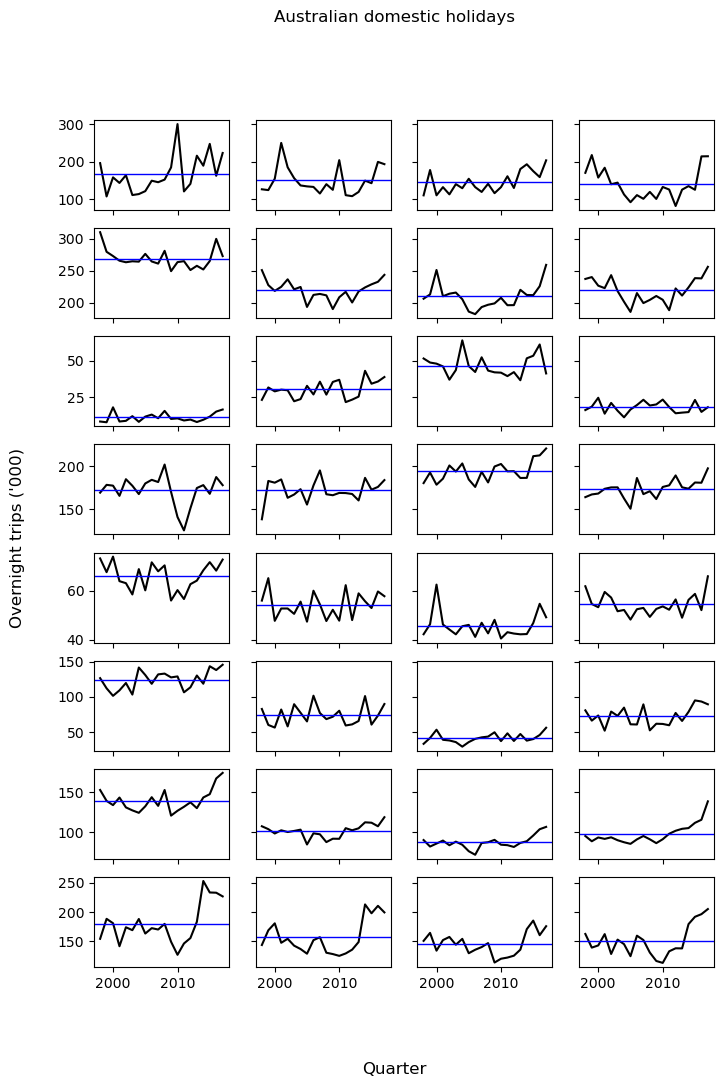

In [144]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))


for ax, ((state, quarter), sq_df) in zip(
        axes.flat, df.groupby(["State", "Quarter"])):
    sq_df = (
    sq_df.groupby("Year", as_index=False)["y"]
    .mean()
    .sort_values("Year")
    )
    ax.plot(sq_df["Year"], sq_df["y"], color="k")
    ax.axhline(sq_df["y"].mean(), color="b", linewidth=1)

fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

In [ ]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))
for ax, ((state, quarter), sq_df) in zip(
        axes.flat, df.groupby(["State", "Quarter"])):
    ax.plot(sq_df["Year"], sq_df["y"], color="k")
    ax.axhline(sq_df["y"].mean(), color="b", linewidth=1)
    ax.tick_params(axis="x", rotation=90)
    xticks = sq_df["Year"].loc[lambda x: (x % 5) == 0]
    if ax in axes[0]:
        ax.set(title=quarter, xticks=xticks)
    if ax in axes[:, -1]:
        ax.text(1.02, 0.5, state, va="center", ha="left", rotation=270,
            size="medium", transform=ax.transAxes)
fig.suptitle("Australian domestic holidays")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

In [ ]:
df = trips.assign(
    Quarter="Q" + trips["ds"].dt.quarter.astype("string"),
    Year=trips["ds"].dt.year,
)
num_states, num_years = df[["State", "Year"]].nunique()
palette = sns.color_palette("husl", num_years)
fig, axes = plt.subplots(num_states, sharex=True, figsize=(8, 10))
for ax, (state, state_df) in zip(axes, df.groupby("State")):
    sns.lineplot(data=state_df, x="Quarter", y="y",
        hue="Year", palette=palette, ax=ax)
    ax.get_legend().remove()
    ax.set(ylabel="")
    ax.text(1.02, 0.5, state, va="center", ha="right", rotation=270,
        size="medium", transform=ax.transAxes)
handles, labels = ax.get_legend_handles_labels()
for h in handles:
    h.set(linewidth=4)
fig.legend(handles, labels, title="Year", loc="center left",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.suptitle("Australian domestic holidays")
fig.supylabel("Overnight trips ('000)")
fig.show()